## 4R3C Thermal Building Model

To capture the thermal inertia of building envelopes more accurately than a simple **1R1C** model, a **2R2C network** can be introduced. The model separates the building into two thermal states:

- **Indoor air temperature** $T_i$
- **Wall (thermal mass) temperature** $T_w$

The system includes:

- Thermal capacitance of indoor air $k_a$.
- Thermal capacitance of the wall $k_w$.
- Thermal conductance between indoor air and wall $G_a$.
- Thermal conductance between wall and outdoor environment $G_w$.

External inputs to the system are:

- Outdoor temperature $T_o$.
- Heating power supplied to the building $\dot{Q}_h$.

## Demonstration

We consider a single building envelope under the 2R2C model and further assume we have a controller that can instantaneously supply heating power $\dot{Q}_h$ to the building envelope. We further assume a simple thermostat setpoint schedule:

$$
T_\text{set} = 21^\circ \text{if daytime, else} \ 18^\circ
$$

where daytime occurs between $08.00$ AM and $21.00$ PM. 

The controller supplies heating power to the building whenever $T_i < T_\text{set}$ and starts to apply the maximum heating power $\dot{Q}_h = \dot{Q}_\text{max}$ else, the controller does nothing $\dot{Q}_h = 0$.

In [24]:
import matplotlib.pyplot as plt
from pydas.RCBuildings import RCBuilding4R3C # Importing necessary simulator tools.
from pydas.controllers import SupplyController
from pydas.utilities import ClimateData

fixed_ground_temperature = 10.0 # Fixed ground temperature of ~ 10 degree Celsius.
thermal_resistances = {"R1": 200.0, "R2": 100.0, "R3": 30.0, "R4": 50.0} # Thermal resistance in K / Kw.
thermal_capacitances = {"C1": 0.56, "C2": 0.56, "C3": 0.83} # Thermal resistance in kwH / K.

In [25]:
df_air_temp = ClimateData.load_csv_from_smhi("../data/smhi_got_lufttemperatur.csv")
controller = SupplyController(maximum_heating_power = 0.5) # An external "controller" that supplies heating power instantaneously.
rcbuilding = RCBuilding4R3C(timestep = 1.0, thermal_resistances = thermal_resistances, thermal_capacitances = thermal_capacitances) # Represent a 4R3C model of building heat loss as first test.


In [26]:
recorded_indoor_temperatures = []
recorded_insulation_temperatures = []
recorded_wall_temperatures = []
recorded_setpoints = []
number_of_iterations = len(df_air_temp.index)
print(f"Simulation will contain {number_of_iterations} one-hour timesteps.")

Simulation will contain 3141 one-hour timesteps.


In [27]:
%%time
rcbuilding.input["ground_temperature"] = fixed_ground_temperature

for it in range(number_of_iterations):
    current_timestep = rcbuilding.current_timestep
    time_of_day = df_air_temp["timestamp"].dt.hour[it]
    recorded_setpoints.append(rcbuilding.get_day_night_setpoint(time_of_day)) # Get the current setpoint temperature, based on a very simple rule.
    recorded_indoor_temperatures.append(rcbuilding.state["indoor_temperature"]) # Get the corresponding instantaneous indoor temperature.
    recorded_insulation_temperatures.append(rcbuilding.state["T2"]) # T2 is interpreted as the temperature of an external wall in the building model.
    recorded_wall_temperatures.append(rcbuilding.state["T3"]) # T2 is interpreted as the temperature of an external wall in the building model.  
    rcbuilding.input["outdoor_temperature"]  = df_air_temp["Lufttemperatur"][current_timestep]
    rcbuilding.input["external_heating"] = controller.setpoint_schedule(rcbuilding = rcbuilding, time_of_day = time_of_day)
    rcbuilding.step() # Update the simulation one hour forward (one timestep).

CPU times: total: 938 ms
Wall time: 996 ms


(300.0, 600.0)

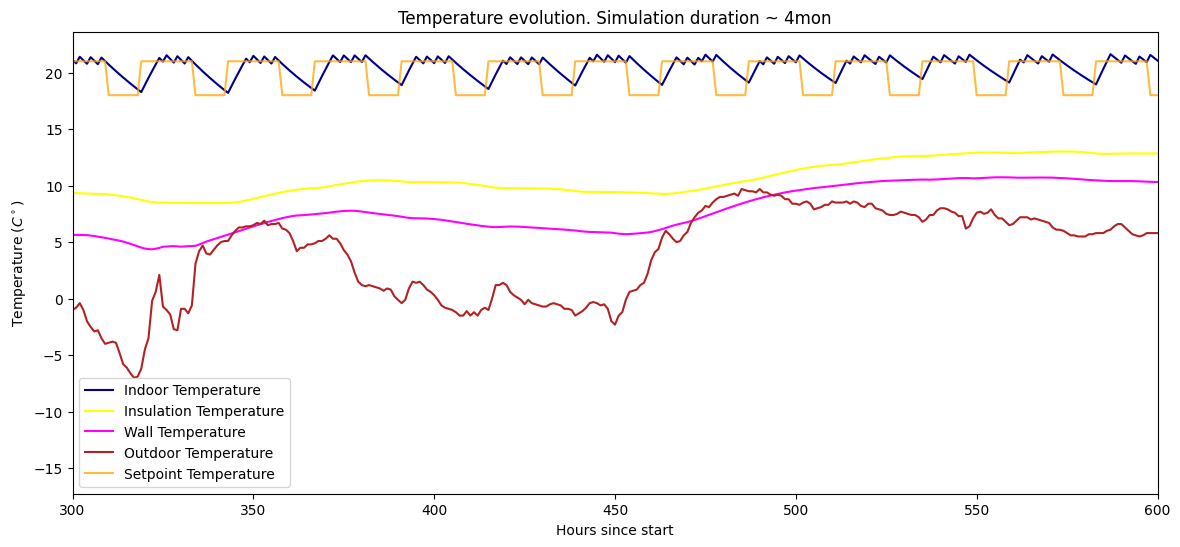

In [29]:
plt.figure(figsize = (14, 6))
plt.plot(recorded_indoor_temperatures, label = "Indoor Temperature", color = "darkblue")
plt.plot(recorded_insulation_temperatures, label = "Insulation Temperature", color = "yellow")
plt.plot(recorded_wall_temperatures, label = "Wall Temperature", color = "magenta")
plt.plot(df_air_temp["Lufttemperatur"], label = "Outdoor Temperature", color = "firebrick")
plt.plot(recorded_setpoints, color = "orange", label = "Setpoint Temperature", alpha = 0.75)
plt.title("Temperature evolution. Simulation duration ~ 4mon")
plt.xlabel("Hours since start")
plt.ylabel("Temperature $(C^\\circ)$")
plt.legend()

plt.xlim(300, 600)